Dataset loaded successfully.

Dataset shape:
(7043, 21)

FIRST 10 ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



MISSING VALUES
0

DUPLICATE ROWS
0

FEATURE MATRIX SHAPE
(7043, 20)

TARGET SHAPE
(7043,)

NUMBER OF NUMERICAL FEATURES:
3

FEATURES USED FOR BOX PLOTS:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


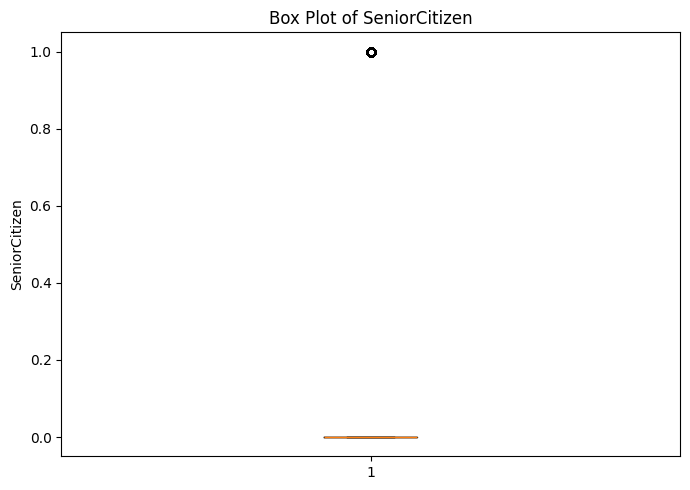

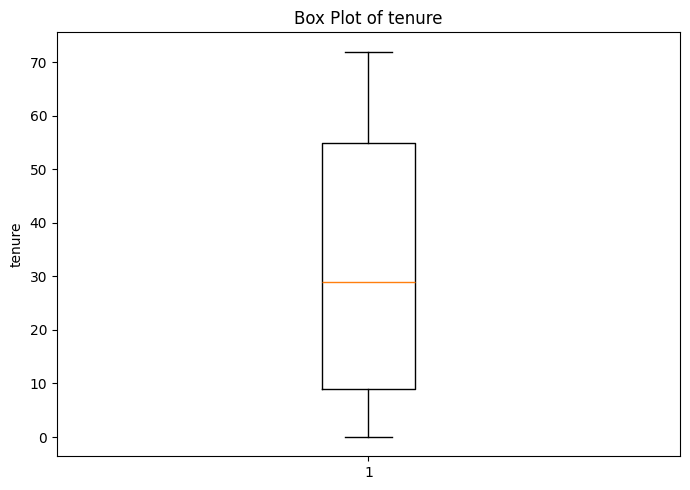

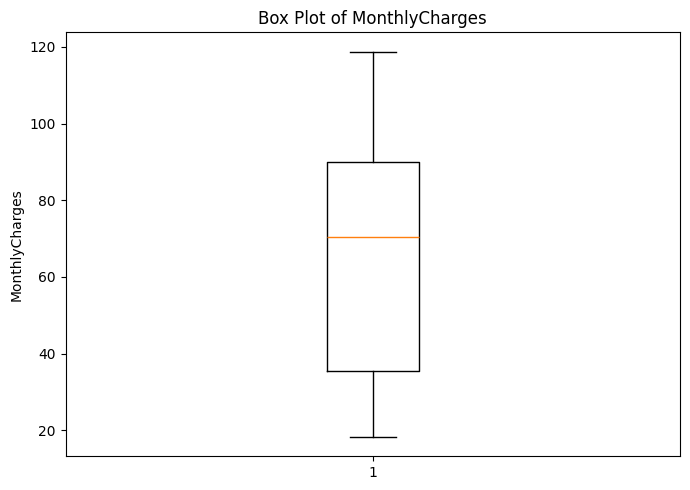


IQR OUTLIER ANALYSIS


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Outlier Percentage
0,SeniorCitizen,0.0,0.00,0.00,0.000,0.000,1142,16.214681
1,tenure,9.0,55.00,46.00,-60.000,124.000,0,0.000000
2,MonthlyCharges,35.5,89.85,54.35,-46.025,171.375,0,0.000000



Z-SCORE OUTLIER ANALYSIS


,Feature,Number of Z-Score Outliers,Percentage
0,SeniorCitizen,0,0.0
1,tenure,0,0.0
2,MonthlyCharges,0,0.0



OUTLIER METHOD COMPARISON


,Feature,Number of Outliers,Outlier Percentage,Number of Z-Score Outliers,Percentage
0,SeniorCitizen,1142,16.214681,0,0.0
1,tenure,0,0.000000,0,0.0
2,MonthlyCharges,0,0.000000,0,0.0



OUTLIER TREATMENT DECISION

Outliers were detected using both IQR and Z-score methods.

The presence of an outlier does not automatically mean that
the observation is incorrect. In an employee dataset, extreme
values may represent genuine employees with unusually high
income, age, experience, or tenure.

Therefore, extreme observations are not automatically deleted.
This prevents the loss of potentially meaningful employee
records.

The IQR and Z-score results are documented for transparency.
The model-ready dataset retains valid observations.



KeyError: 'Churn'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import zscore

from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier


# LOAD THE ENCODED AND SCALED DATASET

df = pd.read_csv(
    "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("Dataset loaded successfully.")

print("\nDataset shape:")

print(df.shape)


# DISPLAY THE DATASET

print(
    "\nFIRST 10 ROWS"
)

display(
    df.head(10)
)


# CHECK FOR MISSING VALUES

print(
    "\nMISSING VALUES"
)

print(
    df.isnull().sum().sum()
)


# CHECK FOR DUPLICATES

print(
    "\nDUPLICATE ROWS"
)

print(
    df.duplicated().sum()
)


# SEPARATE FEATURES AND TARGET

# Find the actual target column name (case-insensitive and stripping whitespace)
target_col_name = None
for col in df.columns:
    if col.strip().lower() == "churn": # Assuming 'Churn' is the correct target column name
        target_col_name = col
        break

if target_col_name:
    X = df.drop(
        target_col_name,
        axis=1
    )

    y = df[target_col_name]
else:
    print("Error: 'Churn' column not found in the DataFrame. Available columns:")
    print(df.columns.tolist())
    raise KeyError("Target column 'Churn' not found.")


print(
    "\nFEATURE MATRIX SHAPE"
)

print(X.shape)


print(
    "\nTARGET SHAPE"
)

print(y.shape)


# PART A - OUTLIER DETECTION


# SELECT NUMERICAL FEATURES

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print(
    "\nNUMBER OF NUMERICAL FEATURES:"
)

print(
    len(numerical_features)
)


# BOX PLOT FOR OUTLIER DETECTION

# Select important continuous variables where possible.
# Use the identified numerical_features directly for box plots
boxplot_features = numerical_features


print(
    "\nFEATURES USED FOR BOX PLOTS:"
)

print(boxplot_features)


# Create box plots

for column in boxplot_features:

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        X[column]
    )

    plt.title(
        f"Box Plot of {column}"
    )

    plt.ylabel(
        column
    )

    plt.tight_layout()

    plt.show()


# IQR OUTLIER DETECTION

def find_iqr_outliers(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)

    upper_bound = Q3 + (1.5 * IQR)

    outlier_mask = (
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    )

    return (
        outlier_mask,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound
    )


# APPLY IQR TO IMPORTANT FEATURES

iqr_results = []


for column in boxplot_features:

    (
        outlier_mask,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound
    ) = find_iqr_outliers(
        X,
        column
    )

    number_of_outliers = (
        outlier_mask.sum()
    )

    percentage = (
        number_of_outliers /
        len(X)
    ) * 100

    iqr_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": number_of_outliers,
        "Outlier Percentage": percentage
    })


iqr_results_df = pd.DataFrame(
    iqr_results
)


print(
    "\nIQR OUTLIER ANALYSIS"
)

display(
    iqr_results_df
)


# Z-SCORE OUTLIER DETECTION

print(
    "\nZ-SCORE OUTLIER ANALYSIS"
)


zscore_results = []


for column in boxplot_features:

    scores = zscore(
        X[column]
    )

    outlier_mask = (
        np.abs(scores) > 3
    )

    number_of_outliers = (
        outlier_mask.sum()
    )

    percentage = (
        number_of_outliers /
        len(X)
    ) * 100

    zscore_results.append({
        "Feature": column,
        "Number of Z-Score Outliers":
            number_of_outliers,
        "Percentage":
            percentage
    })


zscore_results_df = pd.DataFrame(
    zscore_results
)


display(
    zscore_results_df
)


# COMPARE IQR AND Z-SCORE RESULTS

outlier_comparison = iqr_results_df[
    [
        "Feature",
        "Number of Outliers",
        "Outlier Percentage"
    ]
].merge(
    zscore_results_df,
    on="Feature"
)


print(
    "\nOUTLIER METHOD COMPARISON"
)

display(
    outlier_comparison
)


# OUTLIER TREATMENT DECISION

print(
    "\nOUTLIER TREATMENT DECISION"
)

print("""
Outliers were detected using both IQR and Z-score methods.

The presence of an outlier does not automatically mean that
the observation is incorrect. In an employee dataset, extreme
values may represent genuine employees with unusually high
income, age, experience, or tenure.

Therefore, extreme observations are not automatically deleted.
This prevents the loss of potentially meaningful employee
records.

The IQR and Z-score results are documented for transparency.
The model-ready dataset retains valid observations.
""")


# PART B - CORRELATION ANALYSIS


# CORRELATION WITH CHURN

correlation_data = df.corr(
    numeric_only=True
)


attrition_correlation = (
    correlation_data[target_col_name]
    .sort_values(
        ascending=False
    )
)


print(
    "\nCORRELATION WITH CHURN"
)

display(
    attrition_correlation
)


# ABSOLUTE CORRELATION

absolute_correlation = (
    attrition_correlation
    .drop(target_col_name)
    .abs()
    .sort_values(
        ascending=False
    )
)


print(
    "\nFEATURES RANKED BY ABSOLUTE CORRELATION"
)

display(
    absolute_correlation
)


# CORRELATION VISUALISATION

top_correlation_features = (
    absolute_correlation
    .head(15)
    .index
)


plt.figure(figsize=(10, 7))

plt.barh(
    top_correlation_features[::-1],
    absolute_correlation[
        top_correlation_features
    ][::-1]
)

plt.title(
    "Top Features by Absolute Correlation with Churn"
)

plt.xlabel(
    "Absolute Correlation"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()


# PART C - VARIANCE THRESHOLD


# CHECK FEATURE VARIANCE

feature_variance = (
    X.var(
        numeric_only=True
    )
    .sort_values()
)


print(
    "\nFEATURE VARIANCE"
)

display(
    feature_variance
)


# APPLY VARIANCE THRESHOLD

# A very low variance means that a feature has almost the
# same value for every observation and therefore provides
# limited information.

variance_selector = VarianceThreshold(
    threshold=0.01
)


X_variance_selected_array = (
    variance_selector.fit_transform(X)
)


selected_variance_features = (
    X.columns[
        variance_selector.get_support()
    ]
)


X_variance_selected = pd.DataFrame(
    X_variance_selected_array,
    columns=selected_variance_features,
    index=X.index
)


print(
    "\nNumber of features before variance selection:",
    X.shape[1]
)


print(
    "Number of features after variance selection:",
    X_variance_selected.shape[1]
)


print(
    "\nFEATURES RETAINED AFTER VARIANCE THRESHOLD"
)

print(
    selected_variance_features.tolist()
)


# PART D - RANDOM FOREST FEATURE IMPORTANCE


# TRAIN RANDOM FOREST FOR FEATURE IMPORTANCE

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)


rf_model.fit(
    X_variance_selected,
    y
)


# CALCULATE FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "Feature":
        X_variance_selected.columns,

    "Importance":
        rf_model.feature_importances_
})


feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)


print(
    "\nRANDOM FOREST FEATURE IMPORTANCE"
)

display(
    feature_importance
)


# VISUALISE FEATURE IMPORTANCE

top_features = (
    feature_importance
    .head(15)
)


plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top 15 Features by Random Forest Importance"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()


# SELECT IMPORTANT FEATURES

# Select features with importance >= 0.01

importance_threshold = 0.01


important_features = (
    feature_importance[
        feature_importance["Importance"]
        >= importance_threshold
    ]["Feature"]
    .tolist()
)


print(
    "\nNUMBER OF IMPORTANT FEATURES:"
)

print(
    len(important_features)
)


print(
    "\nSELECTED FEATURES:"
)

print(
    important_features
)


# CREATE FINAL FEATURE SET

X_final = X_variance_selected[
    important_features
].copy()


print(
    "\nFINAL FEATURE MATRIX SHAPE:"
)

print(
    X_final.shape
)


# ADD TARGET VARIABLE

final_ml_dataset = X_final.copy()

final_ml_dataset[target_col_name] = y.values


# CHECK FINAL DATASET

print(
    "\nFINAL MACHINE-LEARNING DATASET"
)

display(
    final_ml_dataset.head(10)
)


# CHECK FINAL DATA TYPES

print(
    "\nFINAL DATA TYPES"
)

print(
    final_ml_dataset.dtypes
)


# CHECK MISSING VALUES

print(
    "\nMISSING VALUES"
)

print(
    final_ml_dataset.isnull().sum().sum()
)


# CHECK DUPLICATES

print(
    "\nDUPLICATE ROWS"
)

print(
    final_ml_dataset.duplicated().sum()
)


# FINAL DATASET SHAPE

print(
    "\nFINAL DATASET SHAPE"
)

print(
    final_ml_dataset.shape
)


# SAVE FINAL DATASET

output_file = (
    "HR_Employee_Attrition_ML_Ready.csv"
)


final_ml_dataset.to_csv(
    output_file,
    index=False
)


print(
    "\nFinal machine-learning-ready dataset saved as:"
)

print(
    output_file
)


# FINAL SUMMARY

print(
    "\nPART 5 COMPLETED SUCCESSFULLY"
)

print(
    "\nOriginal number of features:",
    X.shape[1]
)

print(
    "After variance selection:",
    X_variance_selected.shape[1]
)

print(
    "Final selected features:",
    X_final.shape[1]
)

print(
    "Final dataset rows:",
    final_ml_dataset.shape[0]
)

print(
    "Final dataset columns:",
    final_ml_dataset.shape[1]
)

print(
    "\nMissing values:",
    final_ml_dataset.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    final_ml_dataset.duplicated().sum()
)

print(
    "\nThe dataset is now ready for machine-learning model development."
)
